To run this notebook is required to have the necessary model checkpoints in the models\ directory, if they are not there pleas run the [KD_and_LTH_multiple_models_training](KD_and_LTH_multiple_models_training.ipynb) notebook first to train the required models and save the checkpoints

In this section I try to justify the better performance of LTH as a compression method showing that 
1) Lottery tickets have higher CKA with their dense model counterpart than student models have with teacher model counterpart; To do this I will train some tickets starting form the same dense model and same dense inizialization differentating the tickets by randomizing the Gradient descent by randomazing the data loader order, I will do the same to obtain some students models startitng form the same Teacher. Then I will show the average CKA between Dense model and tikets and the average CKA between Teacher and students. If lottery tickets mantain higher CKA than Students this means that LT learn representations more alligned with the Bigger model
2) For the models trained as in last point I will also verify LMC between the Dense and the sparse models as per paper Frankle et al., “Linear Mode Connectivity and the Lottery Ticket Hypothesis” (ICML 2020) LMC between the models should exist and show that dense and tickets models are functionally alligned, this is surprising because the Dense and sparse model are different but the intuition comes from the fact that the sparse model could "live" in a sub-space of aproximabkle functions of the space of the dense model, this is not trivial for KD since Teacher and Student model are two modesls completely unrelated and for this reason is not even possible to interpolate the two models to verify LMC as defined in the Frankle et al. paper.

In [1]:
import torch
import wandb
from torch.optim.lr_scheduler import CosineAnnealingLR
from training import train_epoch, eval_epoch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune

from cka_utils import compute_cka_matrix

from lth_utils import get_prunable_layers, train_model, remove_pruning_reparam, count_sparsity, count_active_parameters

from models import TeacherCNN, StudentCNN, BigCNN

In [2]:
from mnist1d_dataset import get_mnist1d_datasets
from torch.utils.data import DataLoader
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_ds, test_ds = get_mnist1d_datasets()

train_loader = DataLoader(
    train_ds,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=256,
    shuffle=False
)

File already exists. Skipping download.
Successfully loaded data from ./mnist1d_data.pkl


## CKA comparison

### Knoledge Distillation CKA Teacher vs Students

In [3]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher = TeacherCNN().to(device)
teacher.load_state_dict(torch.load("models/best_teacher_model.pth"))

final_loss, final_acc = eval_epoch(teacher, test_loader, nn.CrossEntropyLoss(), device)

print(f"Teacher model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")
print("-" * 60)

import torch
import numpy as np

# Configuration
num_students = 10
teacher_layers = {'fc2': 'classifier.4'}
student_layers = {"fc": "classifier.1"}
criterion = torch.nn.CrossEntropyLoss()

# To store values for final statistics
cka_values = []
acc_values = []

print(f"{'Model':<12} | {'Acc (%)':<10} | {'Loss':<10} | {'CKA Similarity':<15}")
print("-" * 60)

for i in range(num_students):
    model_path = f"models/best_kd_student_{i}.pth"
    
    try:
        student = StudentCNN().to(device)
        student.load_state_dict(torch.load(model_path, map_location=device))
        student.eval()
        
        # 1. Performance Evaluation
        loss, acc = eval_epoch(student, test_loader, criterion, device=device)
        
        # 2. Representation Evaluation
        cka_matrix, _, _ = compute_cka_matrix(
            teacher,
            student,
            teacher_layers,
            student_layers,
            train_loader,
            device
        )
        similarity = cka_matrix[0][0]
        
        # 3. Store results
        cka_values.append(similarity)
        acc_values.append(acc)
        
        print(f"Student {i:<3} | {acc*100:>7.2f}% | {loss:>8.4f} | {similarity:>12.4f}")
        
        del student
        torch.cuda.empty_cache()

    except FileNotFoundError:
        continue

# --- Final Statistical Summary ---
print("-" * 60)
if cka_values:
    mean_cka = np.mean(cka_values)
    std_cka = np.std(cka_values)
    mean_acc = np.mean(acc_values)
    
    print(f"CKA MEAN: {mean_cka:.4f} | CKA STD:  {std_cka:.4f}  | AVG ACC:  {mean_acc*100:.2f}%")
else:
    print("No models were found to evaluate.")

Teacher model - Acc: 0.9940 | Loss: 0.0279
------------------------------------------------------------
Model        | Acc (%)    | Loss       | CKA Similarity 
------------------------------------------------------------
Student 0   |   97.20% |   0.1077 |       0.8261
Student 1   |   97.10% |   0.1188 |       0.8589
Student 2   |   96.20% |   0.1334 |       0.7982
Student 3   |   96.70% |   0.1761 |       0.8180
Student 4   |   96.70% |   0.1351 |       0.8520
Student 5   |   95.80% |   0.1889 |       0.8141
Student 6   |   96.70% |   0.1277 |       0.8245
Student 7   |   96.30% |   0.1555 |       0.8028
Student 8   |   97.60% |   0.1066 |       0.8477
Student 9   |   96.50% |   0.1404 |       0.7578
------------------------------------------------------------
CKA MEAN: 0.8200 | CKA STD:  0.0284  | AVG ACC:  96.68%


### LTH CKA Dense models vs Sparse models

In [4]:
dense_model = BigCNN().to(device)
dense_model.load_state_dict(torch.load("models/lth/dense_model_run0.pth", map_location=device))
dense_model.eval()
final_loss, final_acc = eval_epoch(dense_model, test_loader, nn.CrossEntropyLoss(), device=device)

print(f"Dense model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

print("-" * 60)

layers = { 
        "fc": "classifier.1"
    }

# To store values for final statistics
cka_values = []
acc_values = []

print(f"{'Model':<12} | {'Acc (%)':<10} | {'Loss':<10} | {'CKA Similarity':<15}")
print("-" * 60)

for i in range(10):
    pruned_model = BigCNN().to(device)
    # Apply pruning structure FIRST
    parameters_to_prune = get_prunable_layers(pruned_model)
    for m, p in parameters_to_prune:
        prune.identity(m, p)

    pruned_model.load_state_dict(torch.load(f"models/lth/ticket_model_run{i}.pth", map_location=device))
    # 1. Performance Evaluation
    loss, acc = eval_epoch(pruned_model, test_loader, nn.CrossEntropyLoss(), device=device)

    # 2. Representation Evaluation
    cka_matrix, s_names, b_names = compute_cka_matrix(
        dense_model,
        pruned_model,
        layers,
        layers,
        test_loader,
        device
    )
    similarity = cka_matrix[0][0]

     # 3. Store results
    cka_values.append(similarity)
    acc_values.append(acc)
        
    print(f"Sparse model {i:<3} | {acc*100:>7.2f}% | {loss:>8.4f} | {similarity:>12.4f}")
        
    del pruned_model
    torch.cuda.empty_cache()

# --- Final Statistical Summary ---
print("-" * 60)
if cka_values:
    mean_cka = np.mean(cka_values)
    std_cka = np.std(cka_values)
    mean_acc = np.mean(acc_values)
    
    print(f"CKA MEAN: {mean_cka:.4f} | CKA STD:  {std_cka:.4f}  | AVG ACC:  {mean_acc*100:.2f}%")
else:
    print("No models were found to evaluate.")
    

Dense model - Acc: 0.9930 | Loss: 0.0371
------------------------------------------------------------
Model        | Acc (%)    | Loss       | CKA Similarity 
------------------------------------------------------------
Sparse model 0   |   98.70% |   0.0524 |       0.9448
Sparse model 1   |   97.70% |   0.0796 |       0.9201
Sparse model 2   |   98.50% |   0.0686 |       0.9225
Sparse model 3   |   98.60% |   0.0637 |       0.9132
Sparse model 4   |   98.30% |   0.0762 |       0.9165
Sparse model 5   |   99.00% |   0.0635 |       0.9209
Sparse model 6   |   98.40% |   0.0617 |       0.9346
Sparse model 7   |   98.60% |   0.0597 |       0.9148
Sparse model 8   |   98.50% |   0.0515 |       0.9288
Sparse model 9   |   98.50% |   0.0786 |       0.9254
------------------------------------------------------------
CKA MEAN: 0.9242 | CKA STD:  0.0093  | AVG ACC:  98.48%


## Linear mode connectivity between dense and sparse models

In [5]:
import numpy as np
dense_model = BigCNN().to(device)
dense_model.load_state_dict(torch.load("models/lth/dense_model_run0.pth", map_location=device))
dense_model.eval()
final_loss, final_acc = eval_epoch(dense_model, test_loader, nn.CrossEntropyLoss(), device=device)

print(f"Dense model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

sparse_model = BigCNN().to(device)
# Apply pruning structure FIRST
parameters_to_prune = get_prunable_layers(sparse_model)
for m, p in parameters_to_prune:
    prune.identity(m, p)
sparse_model.load_state_dict(torch.load("models/lth/ticket_model_run0.pth", map_location=device))
final_loss, final_acc = eval_epoch(sparse_model, test_loader, nn.CrossEntropyLoss(), device=device)
count_active_parameters(sparse_model)
print(f"Sparse model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")


import torch
import copy

def update_bn_stats(model, train_loader, device):
    """
    Recalibrates Batch Normalization statistics by performing 
    a forward pass through the training data.
    """
    model.train()  # Set to train mode to allow BN updates
    with torch.no_grad():
        # Typically, a few dozen batches are enough to stabilize stats
        for i, (images, _) in enumerate(train_loader):
            images = images.to(device)
            model(images)
            if i > 20: # Optimization: only use partial train set for speed
                break
    model.eval()

def get_interpolated_model(dense_model, sparse_model, alpha, train_loader, device):
    """
    Creates an interpolated model and recalibrates BN.
    """
    # 1. Clone the dense model structure
    interp_model = copy.deepcopy(dense_model)
    d_weights = dense_model.state_dict()
    s_weights = sparse_model.state_dict()
    
    new_weights = {}
    for key in d_weights:
        # 2. Logic to handle pruned weight keys vs standard weight keys
        if key in s_weights:
            s_val = s_weights[key]
        elif key + "_orig" in s_weights:
            # Reconstruct the effective weights: weight_orig * weight_mask
            s_val = s_weights[key + "_orig"] * s_weights[key + "_mask"]
        else:
            # Fallback for keys that might exist in dense but not sparse (rare)
            s_val = d_weights[key]
            
        # 3. Linear Interpolation
        new_weights[key] = (1.0 - alpha) * d_weights[key] + alpha * s_val
    
    interp_model.load_state_dict(new_weights)
    interp_model.to(device)
    
    
    
    return interp_model

layers = { 
        "fc": "classifier.1"
    }

results = []
for alpha in np.linspace(0, 1, 11):
    # Pass the train_loader here to fix the BN stats
    interp_model = get_interpolated_model(dense_model, sparse_model, alpha, train_loader, device)

    cka_matrix, _ , _ = compute_cka_matrix(
        dense_model,
        interp_model,
        layers,
        layers,
        test_loader,
        device
    )

    # 4. CRITICAL: Recalibrate Batch Norm for the new weight landscape
    update_bn_stats(interp_model, train_loader, device)
    # Evaluate on test set
    loss, acc = eval_epoch(interp_model, test_loader, nn.CrossEntropyLoss(), device=device)
    results.append((alpha, loss, acc, cka_matrix[0][0]))
    print(f"Alpha: {alpha:.1f} | Loss: {loss:.4f} | Acc: {acc:.4f} | CKA: {cka_matrix[0][0]:.4f}")


Dense model - Acc: 0.9930 | Loss: 0.0371
Layer: features.0           | Active:      123 /      160 (76.88%)
Layer: features.5           | Active:      964 /    10240 (9.41%)
Layer: features.10          | Active:     2040 /    40960 (4.98%)
Layer: classifier.1         | Active:     4453 /     8192 (54.36%)
Layer: classifier.4         | Active:      498 /      640 (77.81%)
------------------------------------------------------------
TOTAL ACTIVE PARAMETERS: 8,078 / 60,192
GLOBAL DENSITY: 13.42%
Sparse model - Acc: 0.9870 | Loss: 0.0524
Alpha: 0.0 | Loss: 0.0389 | Acc: 0.9920 | CKA: 1.0000
Alpha: 0.1 | Loss: 0.0388 | Acc: 0.9920 | CKA: 0.9987
Alpha: 0.2 | Loss: 0.0397 | Acc: 0.9920 | CKA: 0.9944
Alpha: 0.3 | Loss: 0.0438 | Acc: 0.9870 | CKA: 0.9863
Alpha: 0.4 | Loss: 0.0503 | Acc: 0.9850 | CKA: 0.9733
Alpha: 0.5 | Loss: 0.0615 | Acc: 0.9840 | CKA: 0.9539
Alpha: 0.6 | Loss: 0.0751 | Acc: 0.9760 | CKA: 0.9272
Alpha: 0.7 | Loss: 0.1087 | Acc: 0.9630 | CKA: 0.8943
Alpha: 0.8 | Loss: 0.1523 | 

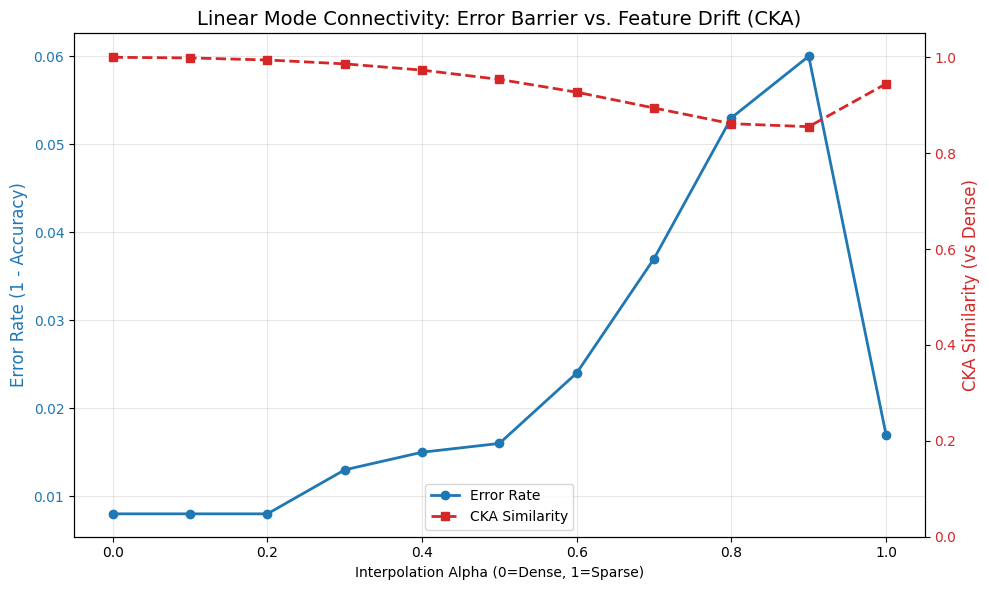

In [6]:
import matplotlib.pyplot as plt

# 1. Extract data (Adjust keys if you used a different structure)
# If using the dictionary format from the last step:
alphas = [r[0] for r in results]
accs = [r[2] for r in results]
errors = [1 - a for a in accs]
ckas = [r[3] for r in results]

# 2. Create the figure and the first axis (Error Rate)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Interpolation Alpha (0=Dense, 1=Sparse)')
ax1.set_ylabel('Error Rate (1 - Accuracy)', color=color, fontsize=12)
ax1.plot(alphas, errors, marker='o', linestyle='-', linewidth=2, color=color, label='Error Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# 3. Create the second axis (CKA) sharing the same x-axis
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('CKA Similarity (vs Dense)', color=color, fontsize=12)
ax2.plot(alphas, ckas, marker='s', linestyle='--', linewidth=2, color=color, label='CKA Similarity')
ax2.tick_params(axis='y', labelcolor=color)

# Set limits for CKA (Similarity is between 0 and 1)
ax2.set_ylim(0, 1.05) 

# 4. Title and Legend
plt.title("Linear Mode Connectivity: Error Barrier vs. Feature Drift (CKA)", fontsize=14)
fig.tight_layout()

# Add a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower center')

plt.savefig("lmc_connectivity_analysis.png")
plt.show()

Why the "Asymmetry" at α=0.9?

The most interesting part of your data is the "instability" that kicks in after α=0.6. This is a classic visualization of the Lottery Ticket Hypothesis geometry.

The Dense Basin (α=0.0 to 0.5): The dense model's solution is "thick." You can move quite far away from the local optimum (adding up to 50% of the sparse model's influence) and the network still performs at 98% accuracy.

The Sparse Basin (α=1.0 to 0.8): The sparse model exists in a much narrower, more fragile valley. Moving just 10% away from the "Winning Ticket" (α=0.9) causes accuracy to tank to 55%. This shows that the specific coordination of weights in a sparse mask is much more sensitive to "noise" from the dense weights than vice-versa.

Does this "verify" LMC?

By the strict definition used in the ICML 2020 paper:

If you define LMC as "no significant increase in error": Your model partially passes at the midpoint but fails near the sparse endpoint.

Stability Test: Frankle et al. would argue that your model is not stable at initialization. To achieve true connectivity (a flat line across all α), they suggest you need to rewind to Epoch k (usually a few hundred or thousand iterations into training).

## How to reach "True" Connectivity

If you want to see that 55% accuracy jump up to >95% (eliminating the barrier entirely), the paper suggests:

Train the dense model for a few iterations (k).

Save those weights (W 
k
​	
 ).

Use W 
k
​	
  as your "initialization" for the LTH pruning process.

Run the interpolation again.

In [7]:
import numpy as np
dense_model = BigCNN().to(device)
dense_model.load_state_dict(torch.load("models/matching/dense_model_run0.pth", map_location=device))
#for module, name in parameters_to_prune:
 #   prune.remove(module, name)
dense_model.eval()
final_loss, final_acc = eval_epoch(dense_model, test_loader, nn.CrossEntropyLoss(), device=device)
print(f"Dense model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

sparse_model = BigCNN().to(device)
parameters_to_prune = get_prunable_layers(sparse_model)
for m, p in parameters_to_prune:
    prune.identity(m, p)
sparse_model.load_state_dict(torch.load("models/matching/matching_model_run0.pth", map_location=device))
final_loss, final_acc = eval_epoch(sparse_model, test_loader, nn.CrossEntropyLoss(), device=device)
#count_active_parameters(sparse_model)
print(f"Sparse model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")


import torch
import copy

def update_bn_stats(model, train_loader, device):
    """
    Recalibrates Batch Normalization statistics by performing 
    a forward pass through the training data.
    """
    model.train()  # Set to train mode to allow BN updates
    with torch.no_grad():
        # Typically, a few dozen batches are enough to stabilize stats
        for i, (images, _) in enumerate(train_loader):
            images = images.to(device)
            model(images)
            if i > 20: # Optimization: only use partial train set for speed
                break
    model.eval()

def get_interpolated_model(dense_model, sparse_model, alpha, train_loader, device):
    """
    Creates an interpolated model and recalibrates BN.
    """
    # 1. Clone the dense model structure
    interp_model = copy.deepcopy(dense_model)
    d_weights = dense_model.state_dict()
    s_weights = sparse_model.state_dict()
    
    new_weights = {}
    for key in d_weights:
        # 2. Logic to handle pruned weight keys vs standard weight keys
        if key in s_weights:
            s_val = s_weights[key]
        elif key + "_orig" in s_weights:
            # Reconstruct the effective weights: weight_orig * weight_mask
            s_val = s_weights[key + "_orig"] * s_weights[key + "_mask"]
        else:
            # Fallback for keys that might exist in dense but not sparse (rare)
            s_val = d_weights[key]
            
        # 3. Linear Interpolation
        new_weights[key] = (1.0 - alpha) * d_weights[key] + alpha * s_val
    
    interp_model.load_state_dict(new_weights)
    interp_model.to(device)
    
    return interp_model

layers = { 
        "fc": "classifier.1"
    }

results = []
for alpha in np.linspace(0, 1, 11):
    # Pass the train_loader here to fix the BN stats
    interp_model = get_interpolated_model(dense_model, sparse_model, alpha, train_loader, device)
    
    cka_matrix, _ , _ = compute_cka_matrix(
        dense_model,
        interp_model,
        layers,
        layers,
        test_loader,
        device
    )
    # 4. CRITICAL: Recalibrate Batch Norm for the new weight landscape
    update_bn_stats(interp_model, train_loader, device)
    # Evaluate on test set
    loss, acc = eval_epoch(interp_model, test_loader, nn.CrossEntropyLoss(), device=device)
    results.append((alpha, loss, acc, cka_matrix[0][0]))
    print(f"Alpha: {alpha:.1f} | Loss: {loss:.4f} | Acc: {acc:.4f} | CKA: {cka_matrix[0][0]:.4f}")


Dense model - Acc: 0.9880 | Loss: 0.0437
Sparse model - Acc: 0.9850 | Loss: 0.0610
Alpha: 0.0 | Loss: 0.0438 | Acc: 0.9880 | CKA: 1.0000
Alpha: 0.1 | Loss: 0.0439 | Acc: 0.9870 | CKA: 0.9996
Alpha: 0.2 | Loss: 0.0451 | Acc: 0.9860 | CKA: 0.9982
Alpha: 0.3 | Loss: 0.0457 | Acc: 0.9850 | CKA: 0.9959
Alpha: 0.4 | Loss: 0.0474 | Acc: 0.9830 | CKA: 0.9926
Alpha: 0.5 | Loss: 0.0502 | Acc: 0.9830 | CKA: 0.9882
Alpha: 0.6 | Loss: 0.0540 | Acc: 0.9830 | CKA: 0.9827
Alpha: 0.7 | Loss: 0.0588 | Acc: 0.9820 | CKA: 0.9764
Alpha: 0.8 | Loss: 0.0641 | Acc: 0.9780 | CKA: 0.9699
Alpha: 0.9 | Loss: 0.0658 | Acc: 0.9800 | CKA: 0.9649
Alpha: 1.0 | Loss: 0.0584 | Acc: 0.9830 | CKA: 0.9646


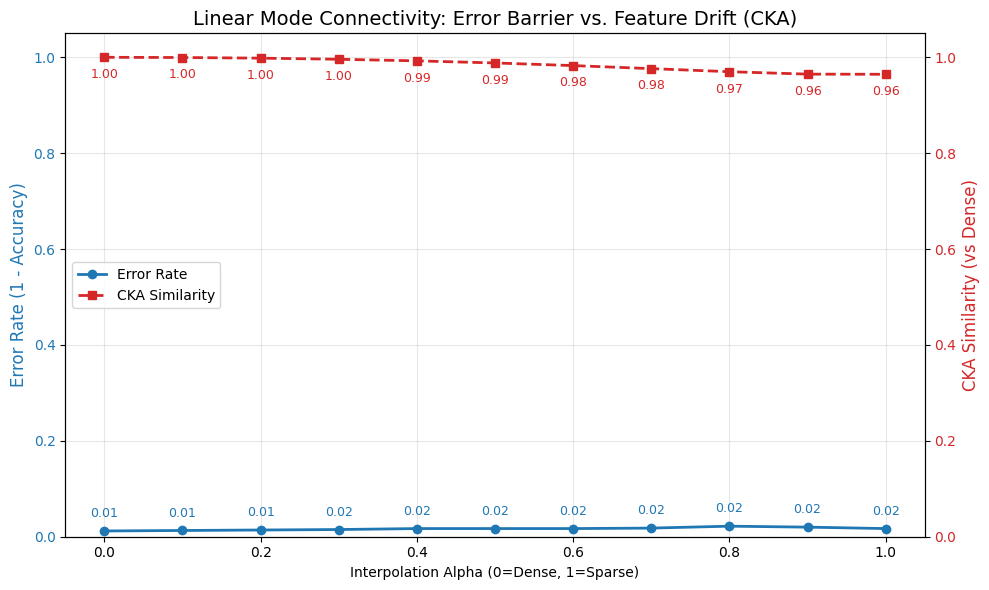

In [9]:
import matplotlib.pyplot as plt

# 1. Extract data (Adjust keys if you used a different structure)
# If using the dictionary format from the last step:
alphas = [r[0] for r in results]
accs = [r[2] for r in results]
errors = [1 - a for a in accs]
ckas = [r[3] for r in results]

# 2. Create the figure and the first axis (Error Rate)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Interpolation Alpha (0=Dense, 1=Sparse)')
ax1.set_ylabel('Error Rate (1 - Accuracy)', color=color, fontsize=12)
ax1.plot(alphas, errors, marker='o', linestyle='-', linewidth=2, color=color, label='Error Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

for x, y in zip(alphas, errors):
    ax1.annotate(f'{y:.2f}', 
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, 10), # 10pt vertical offset
                 ha='center', 
                 fontsize=9, 
                 color='tab:blue')

# 3. Create the second axis (CKA) sharing the same x-axis
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('CKA Similarity (vs Dense)', color=color, fontsize=12)
ax2.plot(alphas, ckas, marker='s', linestyle='--', linewidth=2, color=color, label='CKA Similarity')
ax2.tick_params(axis='y', labelcolor=color)

# Set limits for CKA (Similarity is between 0 and 1)
ax2.set_ylim(0, 1.05) 

for x, y in zip(alphas, ckas):
    ax2.annotate(f'{y:.2f}', 
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, -15), # -15pt offset to put text below the marker
                 ha='center', 
                 fontsize=9, 
                 color='tab:red')

# 4. Title and Legend
plt.title("Linear Mode Connectivity: Error Barrier vs. Feature Drift (CKA)", fontsize=14)
fig.tight_layout()

# Add a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.savefig("lmc_connectivity_matching_models.png")
plt.show()

In [68]:
import numpy as np
dense_model = BigCNN().to(device)
dense_model.load_state_dict(torch.load("models/matching/dense_model_run0.pth", map_location=device))
dense_model.eval()
final_loss, final_acc = eval_epoch(dense_model, test_loader, nn.CrossEntropyLoss(), device=device)
print(f"Dense model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

sparse_model = BigCNN().to(device)
parameters_to_prune = get_prunable_layers(sparse_model)
for m, p in parameters_to_prune:
    prune.identity(m, p)
sparse_model.load_state_dict(torch.load("models/matching/matching_model_run1.pth", map_location=device))
final_loss, final_acc = eval_epoch(sparse_model, test_loader, nn.CrossEntropyLoss(), device=device)
#count_active_parameters(sparse_model)
print(f"Sparse model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")


import torch
import copy

def update_bn_stats(model, train_loader, device):
    """
    Recalibrates Batch Normalization statistics by performing 
    a forward pass through the training data.
    """
    model.train()  # Set to train mode to allow BN updates
    with torch.no_grad():
        # Typically, a few dozen batches are enough to stabilize stats
        for i, (images, _) in enumerate(train_loader):
            images = images.to(device)
            model(images)
            if i > 20: # Optimization: only use partial train set for speed
                break
    model.eval()

def get_interpolated_model(dense_model, sparse_model, alpha, train_loader, device):
    """
    Creates an interpolated model and recalibrates BN.
    """
    # 1. Clone the dense model structure
    interp_model = copy.deepcopy(dense_model)
    d_weights = dense_model.state_dict()
    s_weights = sparse_model.state_dict()
    
    new_weights = {}
    for key in d_weights:
        # 2. Logic to handle pruned weight keys vs standard weight keys
        if key in s_weights:
            s_val = s_weights[key]
        elif key + "_orig" in s_weights:
            # Reconstruct the effective weights: weight_orig * weight_mask
            s_val = s_weights[key + "_orig"] * s_weights[key + "_mask"]
        else:
            # Fallback for keys that might exist in dense but not sparse (rare)
            s_val = d_weights[key]
            
        # 3. Linear Interpolation
        new_weights[key] = (1.0 - alpha) * d_weights[key] + alpha * s_val
    
    interp_model.load_state_dict(new_weights)
    interp_model.to(device)
    
    return interp_model

layers = { 
        "fc": "classifier.1"
    }

results = []
for alpha in np.linspace(0, 1, 11):
    # Pass the train_loader here to fix the BN stats
    interp_model = get_interpolated_model(dense_model, sparse_model, alpha, train_loader, device)
    
    cka_matrix, _ , _ = compute_cka_matrix(
        dense_model,
        interp_model,
        layers,
        layers,
        test_loader,
        device
    )
    # 4. CRITICAL: Recalibrate Batch Norm for the new weight landscape
    update_bn_stats(interp_model, train_loader, device)
    # Evaluate on test set
    loss, acc = eval_epoch(interp_model, test_loader, nn.CrossEntropyLoss(), device=device)
    results.append((alpha, loss, acc, cka_matrix[0][0]))
    print(f"Alpha: {alpha:.1f} | Loss: {loss:.4f} | Acc: {acc:.4f} | CKA: {cka_matrix[0][0]:.4f}")


Dense model - Acc: 0.9880 | Loss: 0.0437
Sparse model - Acc: 0.9840 | Loss: 0.0573
Alpha: 0.0 | Loss: 0.0436 | Acc: 0.9870 | CKA: 1.0000
Alpha: 0.1 | Loss: 0.0437 | Acc: 0.9860 | CKA: 0.9996
Alpha: 0.2 | Loss: 0.0451 | Acc: 0.9850 | CKA: 0.9984
Alpha: 0.3 | Loss: 0.0467 | Acc: 0.9850 | CKA: 0.9963
Alpha: 0.4 | Loss: 0.0487 | Acc: 0.9830 | CKA: 0.9931
Alpha: 0.5 | Loss: 0.0519 | Acc: 0.9820 | CKA: 0.9888
Alpha: 0.6 | Loss: 0.0550 | Acc: 0.9810 | CKA: 0.9832
Alpha: 0.7 | Loss: 0.0588 | Acc: 0.9790 | CKA: 0.9761
Alpha: 0.8 | Loss: 0.0631 | Acc: 0.9780 | CKA: 0.9675
Alpha: 0.9 | Loss: 0.0624 | Acc: 0.9790 | CKA: 0.9597
Alpha: 1.0 | Loss: 0.0558 | Acc: 0.9830 | CKA: 0.9643


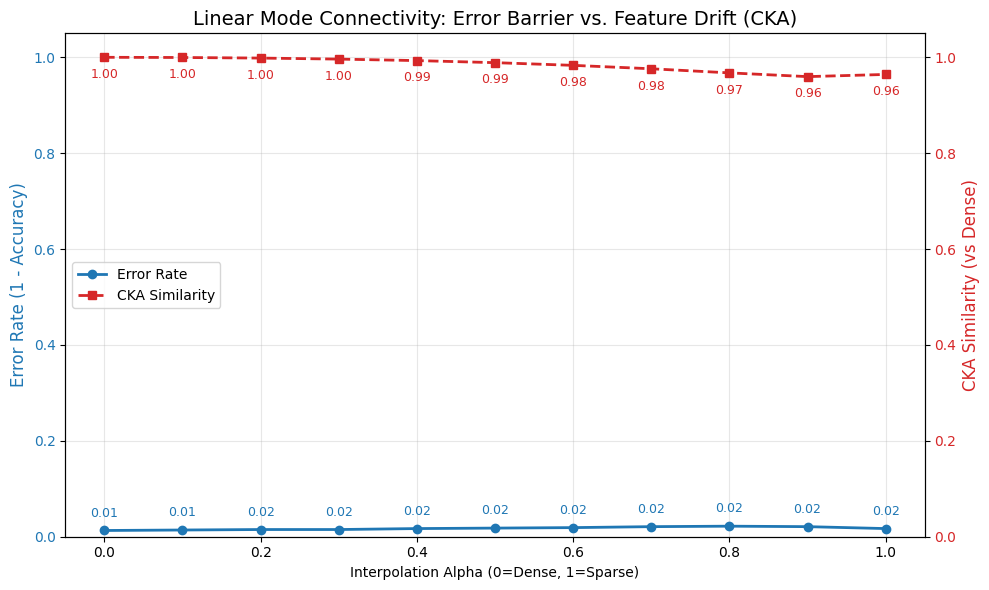

In [69]:
import matplotlib.pyplot as plt

# 1. Extract data (Adjust keys if you used a different structure)
# If using the dictionary format from the last step:
alphas = [r[0] for r in results]
accs = [r[2] for r in results]
errors = [1 - a for a in accs]
ckas = [r[3] for r in results]

# 2. Create the figure and the first axis (Error Rate)
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:blue'
ax1.set_xlabel('Interpolation Alpha (0=Dense, 1=Sparse)')
ax1.set_ylabel('Error Rate (1 - Accuracy)', color=color, fontsize=12)
ax1.plot(alphas, errors, marker='o', linestyle='-', linewidth=2, color=color, label='Error Rate')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

for x, y in zip(alphas, errors):
    ax1.annotate(f'{y:.2f}', 
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, 10), # 10pt vertical offset
                 ha='center', 
                 fontsize=9, 
                 color='tab:blue')

# 3. Create the second axis (CKA) sharing the same x-axis
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('CKA Similarity (vs Dense)', color=color, fontsize=12)
ax2.plot(alphas, ckas, marker='s', linestyle='--', linewidth=2, color=color, label='CKA Similarity')
ax2.tick_params(axis='y', labelcolor=color)

# Set limits for CKA (Similarity is between 0 and 1)
ax2.set_ylim(0, 1.05) 

for x, y in zip(alphas, ckas):
    ax2.annotate(f'{y:.2f}', 
                 xy=(x, y), 
                 textcoords="offset points", 
                 xytext=(0, -15), # -15pt offset to put text below the marker
                 ha='center', 
                 fontsize=9, 
                 color='tab:red')

# 4. Title and Legend
plt.title("Linear Mode Connectivity: Error Barrier vs. Feature Drift (CKA)", fontsize=14)
fig.tight_layout()

# Add a combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.savefig("lmc_connectivity_analysis_matching_different_dense.png")
plt.show()

In [70]:
dense_model1 = BigCNN().to(device)
dense_model1.load_state_dict(torch.load("models/matching/dense_model_run0.pth", map_location=device))
dense_model1.eval()
final_loss, final_acc = eval_epoch(dense_model1, test_loader, nn.CrossEntropyLoss(), device=device)
print(f"Dense model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

dense_model2 = BigCNN().to(device)
dense_model2.load_state_dict(torch.load("models/matching/dense_model_run1.pth", map_location=device))
dense_model2.eval()
final_loss, final_acc = eval_epoch(dense_model2, test_loader, nn.CrossEntropyLoss(), device=device)
print(f"Dense model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

def get_weight_dist(model1, model2):
    p1 = torch.nn.utils.parameters_to_vector(model1.parameters())
    p2 = torch.nn.utils.parameters_to_vector(model2.parameters())
    
    l2_dist = torch.dist(p1, p2, p=2)
    cos_sim = torch.nn.functional.cosine_similarity(p1.unsqueeze(0), p2.unsqueeze(0))
    
    return l2_dist.item(), cos_sim.item()

dist, sim = get_weight_dist(dense_model1, dense_model2)
print(f"L2 Distance: {dist:.4f} | Cosine Similarity: {sim:.4f}")

def get_functional_dissimilarity(model1, model2, loader, device):
    disagreements = 0
    total = 0
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            out1 = model1(inputs).argmax(dim=1)
            out2 = model2(inputs).argmax(dim=1)
            disagreements += (out1 != out2).sum().item()
            total += inputs.size(0)
    return disagreements / total

churn = get_functional_dissimilarity(dense_model1, dense_model2, test_loader, device)
print(f"Prediction Disagreement (Churn): {churn * 100:.2f}%")

cka_matrix, _ , _ = compute_cka_matrix(
        dense_model1,
        dense_model2,
        layers,
        layers,
        test_loader,
        device
    )
print(f"CKA Similarity: {cka_matrix[0][0]:.4f}")


Dense model - Acc: 0.9880 | Loss: 0.0437
Dense model - Acc: 0.9860 | Loss: 0.0472
L2 Distance: 8.5627 | Cosine Similarity: 0.9712
Prediction Disagreement (Churn): 0.20%
CKA Similarity: 0.9887


In [71]:
sparse_model1 = BigCNN().to(device)
parameters_to_prune = get_prunable_layers(sparse_model1)
for m, p in parameters_to_prune:
    prune.identity(m, p)
sparse_model1.load_state_dict(torch.load("models/matching/matching_model_run0.pth", map_location=device))
final_loss, final_acc = eval_epoch(sparse_model1, test_loader, nn.CrossEntropyLoss(), device=device)
#count_active_parameters(sparse_model)
print(f"Sparse model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

sparse_model2 = BigCNN().to(device)
parameters_to_prune = get_prunable_layers(sparse_model2)
for m, p in parameters_to_prune:
    prune.identity(m, p)
sparse_model2.load_state_dict(torch.load("models/matching/matching_model_run1.pth", map_location=device))
final_loss, final_acc = eval_epoch(sparse_model2, test_loader, nn.CrossEntropyLoss(), device=device)
#count_active_parameters(sparse_model)
print(f"Sparse model - Acc: {final_acc:.4f} | Loss: {final_loss:.4f}")

def get_weight_dist(model1, model2):
    p1 = torch.nn.utils.parameters_to_vector(model1.parameters())
    p2 = torch.nn.utils.parameters_to_vector(model2.parameters())
    
    l2_dist = torch.dist(p1, p2, p=2)
    cos_sim = torch.nn.functional.cosine_similarity(p1.unsqueeze(0), p2.unsqueeze(0))
    
    return l2_dist.item(), cos_sim.item()

dist, sim = get_weight_dist(sparse_model1, sparse_model2)
print(f"L2 Distance: {dist:.4f} | Cosine Similarity: {sim:.4f}")

def get_functional_dissimilarity(model1, model2, loader, device):
    disagreements = 0
    total = 0
    with torch.no_grad():
        for inputs, _ in loader:
            inputs = inputs.to(device)
            out1 = model1(inputs).argmax(dim=1)
            out2 = model2(inputs).argmax(dim=1)
            disagreements += (out1 != out2).sum().item()
            total += inputs.size(0)
    return disagreements / total

churn = get_functional_dissimilarity(sparse_model1, sparse_model2, test_loader, device)
print(f"Prediction Disagreement (Churn): {churn * 100:.2f}%")

cka_matrix, _ , _ = compute_cka_matrix(
        sparse_model1,
        sparse_model2,
        layers,
        layers,
        test_loader,
        device
    )
print(f"CKA Similarity: {cka_matrix[0][0]:.4f}")

Sparse model - Acc: 0.9850 | Loss: 0.0610
Sparse model - Acc: 0.9840 | Loss: 0.0573
L2 Distance: 7.0415 | Cosine Similarity: 0.9782
Prediction Disagreement (Churn): 0.70%
CKA Similarity: 0.9763
